In [1]:
import pandas as pd
import numpy as np

In [2]:
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
qualifying = pd.read_csv("../data/qualifying.csv")
drivers = pd.read_csv("../data/drivers.csv")
constructors = pd.read_csv("../data/constructors.csv")
circuits = pd.read_csv("../data/circuits.csv")

In [3]:
print("Races:", races.shape)
print("Results:", results.shape)
print("Qualifying:", qualifying.shape)
print("Drivers:", drivers.shape)
print("Constructors:", constructors.shape)
print("Circuits:", circuits.shape)

Races: (1125, 18)
Results: (26759, 18)
Qualifying: (10494, 9)
Drivers: (861, 9)
Constructors: (212, 5)
Circuits: (77, 9)


In [4]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [5]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [6]:
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [9]:
results

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,20,14,16,16,16,0.0,57,\N,\N,57,1,1:25.637,222.002,11
26755,26761,1144,859,215,30,12,17,17,17,0.0,55,\N,\N,52,12,1:28.751,214.212,5
26756,26762,1144,822,15,77,9,\N,R,18,0.0,30,\N,\N,14,19,1:29.482,212.462,130
26757,26763,1144,861,3,43,20,\N,R,19,0.0,26,\N,\N,5,17,1:29.411,212.631,5


In [10]:
df = results

In [12]:
df = df.merge(
    qualifying,
    on=['raceId','driverId'],
    how='left'
)

In [13]:
df = df.merge(
    races,
    on='raceId',
    how='left'
)

In [16]:
df = df.merge(
    constructors,
    left_on='constructorId_x',
    right_on='constructorId',
    how='left'
)

In [17]:
df = df.merge(
    circuits,
    on='circuitId',
    how='left'
)

In [18]:
df.head()

,resultId,raceId,driverId,constructorId_x,number_x,grid,position_x,positionText,positionOrder,points,...,nationality,url_y,circuitRef,name,location,country,lat,lng,alt,url
0,1,18,1,1,22,1,1,1,1,10.0,...,British,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,18,2,2,3,5,2,2,2,8.0,...,German,http://en.wikipedia.org/wiki/BMW_Sauber,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,3,18,3,3,7,7,3,3,3,6.0,...,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
3,4,18,4,4,5,11,4,4,4,5.0,...,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
4,5,18,5,1,23,3,5,5,5,4.0,...,British,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


In [19]:
df.columns.tolist()

['resultId',
 'raceId',
 'driverId',
 'constructorId_x',
 'number_x',
 'grid',
 'position_x',
 'positionText',
 'positionOrder',
 'points',
 'laps',
 'time_x',
 'milliseconds',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'statusId',
 'qualifyId',
 'constructorId_y',
 'number_y',
 'position_y',
 'q1',
 'q2',
 'q3',
 'year',
 'round',
 'circuitId',
 'name_x',
 'date',
 'time_y',
 'url_x',
 'fp1_date',
 'fp1_time',
 'fp2_date',
 'fp2_time',
 'fp3_date',
 'fp3_time',
 'quali_date',
 'quali_time',
 'sprint_date',
 'sprint_time',
 'constructorId',
 'constructorRef',
 'name_y',
 'nationality',
 'url_y',
 'circuitRef',
 'name',
 'location',
 'country',
 'lat',
 'lng',
 'alt',
 'url']

In [21]:
df.columns.tolist()

['resultId',
 'raceId',
 'driverId',
 'constructorId_x',
 'number_x',
 'grid',
 'position_x',
 'positionText',
 'positionOrder',
 'points',
 'laps',
 'time_x',
 'milliseconds',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'statusId',
 'qualifyId',
 'constructorId_y',
 'number_y',
 'position_y',
 'q1',
 'q2',
 'q3',
 'year',
 'round',
 'circuitId',
 'name_x',
 'date',
 'time_y',
 'url_x',
 'fp1_date',
 'fp1_time',
 'fp2_date',
 'fp2_time',
 'fp3_date',
 'fp3_time',
 'quali_date',
 'quali_time',
 'sprint_date',
 'sprint_time',
 'constructorId',
 'constructorRef',
 'name_y',
 'nationality',
 'url_y',
 'circuitRef',
 'name',
 'location',
 'country',
 'lat',
 'lng',
 'alt',
 'url']

In [22]:
df['podium'] = (df['positionOrder'] <= 3).astype(int)

In [23]:
df['podium'].value_counts()

podium
0    23362
1     3397
Name: count, dtype: int64

In [24]:
for col in df.columns:
    print(col)

resultId
raceId
driverId
constructorId_x
number_x
grid
position_x
positionText
positionOrder
points
laps
time_x
milliseconds
fastestLap
rank
fastestLapTime
fastestLapSpeed
statusId
qualifyId
constructorId_y
number_y
position_y
q1
q2
q3
year
round
circuitId
name_x
date
time_y
url_x
fp1_date
fp1_time
fp2_date
fp2_time
fp3_date
fp3_time
quali_date
quali_time
sprint_date
sprint_time
constructorId
constructorRef
name_y
nationality
url_y
circuitRef
name
location
country
lat
lng
alt
url
podium


In [51]:
f1_podium_dataset = df[
    [
        'grid',
        'position_y',
        'name_y',
        'name',
        'year',
        'podium'
    ]
].copy()

In [52]:
f1_podium_dataset.columns = [
    'grid',
    'qualifying_position',
    'constructor',
    'circuit',
    'year',
    'podium'
]

In [53]:
f1_podium_dataset.head()

,grid,qualifying_position,constructor,circuit,year,podium
0,1,1.0,McLaren,Albert Park Grand Prix Circuit,2008,1
1,5,5.0,BMW Sauber,Albert Park Grand Prix Circuit,2008,1
2,7,7.0,Williams,Albert Park Grand Prix Circuit,2008,1
3,11,12.0,Renault,Albert Park Grand Prix Circuit,2008,0
4,3,3.0,McLaren,Albert Park Grand Prix Circuit,2008,0


In [54]:
f1_podium_dataset.shape

(26759, 6)

In [55]:
f1_podium_dataset.isnull().sum()

grid                       0
qualifying_position    16265
constructor                0
circuit                    0
year                       0
podium                     0
dtype: int64

In [56]:
df[df['position_y'].isnull()]['year'].value_counts().sort_index()

year
1950    160
1951    179
1952    215
1953    246
1954    230
1955    180
1956    190
1957    171
1958    241
1959    195
1960    223
1961    220
1962    223
1963    254
1964    207
1965    205
1966    166
1967    205
1968    233
1969    177
1970    294
1971    263
1972    309
1973    357
1974    436
1975    363
1976    434
1977    477
1978    471
1979    403
1980    383
1981    449
1982    465
1983    424
1984    430
1985    406
1986    412
1987    419
1988    495
1989    620
1990    542
1991    539
1992    478
1993    412
1994     52
1996    192
1997    156
1998    196
1999    287
2000    285
2001    352
2002    320
2011      4
2012      4
2014      2
2015      4
2016      5
2017      2
2019      2
2021      1
Name: count, dtype: int64

In [45]:
df[df['position_y'].isnull()]['year'].value_counts().sort_index()

year
1950    160
1951    179
1952    215
1953    246
1954    230
1955    180
1956    190
1957    171
1958    241
1959    195
1960    223
1961    220
1962    223
1963    254
1964    207
1965    205
1966    166
1967    205
1968    233
1969    177
1970    294
1971    263
1972    309
1973    357
1974    436
1975    363
1976    434
1977    477
1978    471
1979    403
1980    383
1981    449
1982    465
1983    424
1984    430
1985    406
1986    412
1987    419
1988    495
1989    620
1990    542
1991    539
1992    478
1993    412
1994     52
1996    192
1997    156
1998    196
1999    287
2000    285
2001    352
2002    320
2011      4
2012      4
2014      2
2015      4
2016      5
2017      2
2019      2
2021      1
Name: count, dtype: int64

In [57]:
f1_podium_dataset['qualifying_position'] = (
    f1_podium_dataset['qualifying_position']
    .fillna(
        f1_podium_dataset['qualifying_position'].median()
    )
)

In [58]:
f1_podium_dataset.isnull().sum()

grid                   0
qualifying_position    0
constructor            0
circuit                0
year                   0
podium                 0
dtype: int64

In [59]:
f1_podium_dataset.shape

(26759, 6)

In [60]:
f1_podium_dataset['podium'].value_counts()

podium
0    23362
1     3397
Name: count, dtype: int64

In [61]:
f1_podium_dataset['podium'].value_counts(normalize=True)

podium
0    0.873052
1    0.126948
Name: proportion, dtype: float64

In [62]:
f1_podium_dataset.head()

,grid,qualifying_position,constructor,circuit,year,podium
0,1,1.0,McLaren,Albert Park Grand Prix Circuit,2008,1
1,5,5.0,BMW Sauber,Albert Park Grand Prix Circuit,2008,1
2,7,7.0,Williams,Albert Park Grand Prix Circuit,2008,1
3,11,12.0,Renault,Albert Park Grand Prix Circuit,2008,0
4,3,3.0,McLaren,Albert Park Grand Prix Circuit,2008,0


In [63]:
f1_podium_dataset.shape

(26759, 6)

In [64]:
f1_podium_dataset.isnull().sum()

grid                   0
qualifying_position    0
constructor            0
circuit                0
year                   0
podium                 0
dtype: int64

In [65]:
f1_podium_dataset['podium'].value_counts()

podium
0    23362
1     3397
Name: count, dtype: int64

In [66]:
f1_podium_dataset['podium'].value_counts(normalize=True)

podium
0    0.873052
1    0.126948
Name: proportion, dtype: float64

In [67]:
f1_podium_dataset.to_csv(
    '../data/f1_podium_dataset.csv',
    index=False
)

In [68]:
from sklearn.preprocessing import LabelEncoder

In [69]:
constructor_encoder = LabelEncoder()
circuit_encoder = LabelEncoder()

In [70]:
f1_podium_dataset['constructor'] = (
    constructor_encoder.fit_transform(
        f1_podium_dataset['constructor']
    )
)

f1_podium_dataset['circuit'] = (
    circuit_encoder.fit_transform(
        f1_podium_dataset['circuit']
    )
)

In [71]:
X = f1_podium_dataset.drop(
    'podium',
    axis=1
)

y = f1_podium_dataset['podium']

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [75]:
lr_pred = lr.predict(X_test)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [77]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.8863976083707026
Precision: 0.6550218340611353
Recall: 0.22091310751104565
F1: 0.3303964757709251


In [78]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [79]:
lr_pred = lr.predict(X_test)

In [80]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.7406576980568012
Precision: 0.3072321914083741
Recall: 0.8321060382916053
F1: 0.448768864177919


In [81]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.859304932735426
Precision: 0.45707656612529
Recall: 0.5802650957290133
F1: 0.5113562621674238


In [83]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(y_test, rf_probs)
)

ROC AUC: 0.8784678504377763


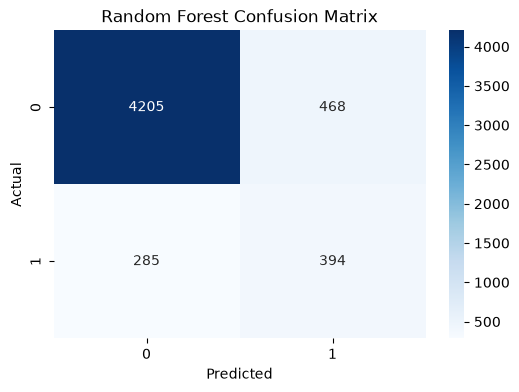

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [85]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

               Feature  Importance
0                 grid    0.425822
4                 year    0.183541
3              circuit    0.168746
2          constructor    0.121819
1  qualifying_position    0.100072


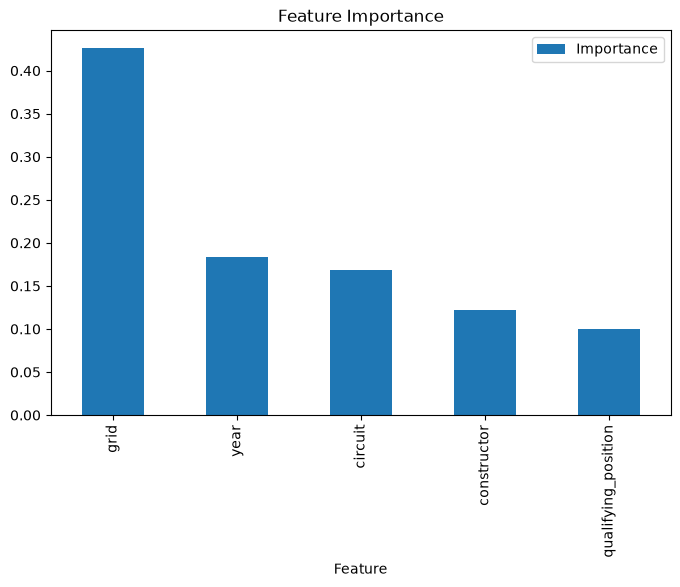

In [86]:
importance_df.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [87]:
f1_podium_dataset['grid_vs_quali'] = (
    f1_podium_dataset['grid']
    - f1_podium_dataset['qualifying_position']
)

In [88]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))

Accuracy: 0.8918161434977578
Precision: 0.6152073732718893
Recall: 0.39322533136966126
F1: 0.4797843665768194


In [90]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, rf_probs)

0.8784678504377763

In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      4673
           1       0.46      0.58      0.51       679

    accuracy                           0.86      5352
   macro avg       0.70      0.74      0.71      5352
weighted avg       0.88      0.86      0.87      5352



In [92]:
import joblib

joblib.dump(
    rf,
    "podium_predictor.pkl"
)

['podium_predictor.pkl']

In [93]:
joblib.dump(
    constructor_encoder,
    "constructor_encoder.pkl"
)

joblib.dump(
    circuit_encoder,
    "circuit_encoder.pkl"
)

['circuit_encoder.pkl']

In [94]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, rf_probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8784678504377763


In [95]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      4673
           1       0.46      0.58      0.51       679

    accuracy                           0.86      5352
   macro avg       0.70      0.74      0.71      5352
weighted avg       0.88      0.86      0.87      5352



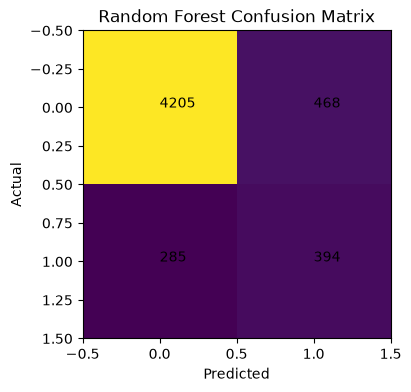

In [96]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j])

plt.show()

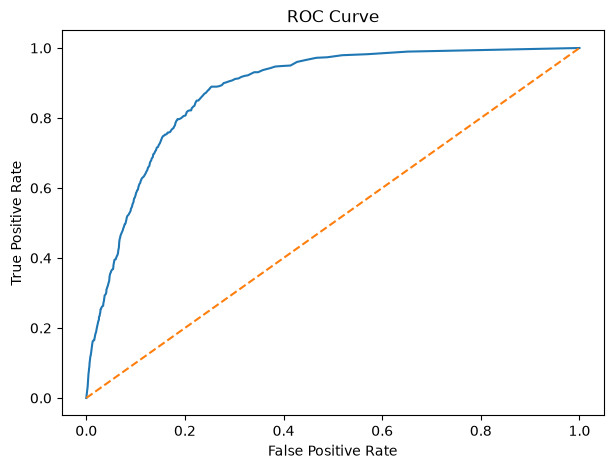

In [97]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [98]:
import joblib

joblib.dump(
    rf,
    "podium_predictor.pkl"
)

['podium_predictor.pkl']

In [99]:
joblib.dump(
    constructor_encoder,
    "constructor_encoder.pkl"
)

joblib.dump(
    circuit_encoder,
    "circuit_encoder.pkl"
)

['circuit_encoder.pkl']

In [100]:
import os

print(os.listdir())

['circuit_encoder.pkl', 'constructor_encoder.pkl', 'F1_Race_Outcome_Predictor.ipynb', 'podium_predictor.pkl']


In [101]:
loaded_model = joblib.load(
    "podium_predictor.pkl"
)

loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 1])

In [102]:
import pandas as pd

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy':[
        0.886,
        0.741,
        0.859,
        0.892
    ],
    'F1 Score':[
        0.330,
        0.449,
        0.511,
        0.480
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.886,0.330
1,Balanced Logistic Regression,0.741,0.449
2,Random Forest,0.859,0.511
3,XGBoost,0.892,0.480


In [103]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, rf_probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8784678504377763


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      4673
           1       0.46      0.58      0.51       679

    accuracy                           0.86      5352
   macro avg       0.70      0.74      0.71      5352
weighted avg       0.88      0.86      0.87      5352

